In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypfopt import expected_returns, risk_models, EfficientFrontier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.base import BaseEstimator
import yfinance as yf

class MarkowitzOptimizer(BaseEstimator):
    """
    Custom estimator for Markowitz portfolio optimization that can be used with scikit-learn's GridSearchCV.
    """
    def __init__(self, risk_aversion=1.0, target_return=None, weight_bounds=(0, 1), 
                 risk_free_rate=0.02, shrinkage_method='ledoit_wolf'):
        self.risk_aversion = risk_aversion
        self.target_return = target_return
        self.weight_bounds = weight_bounds
        self.risk_free_rate = risk_free_rate
        self.shrinkage_method = shrinkage_method
        self.weights_ = None
        self.performance_ = None

    def fit(self, X, y=None):
        """
        Optimize portfolio using training data
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Historical price data for assets
        """
        # Calculate expected returns and covariance matrix
        if X.shape[0] <= 1:
            # Handle case with only one period (can't compute returns)
            self.weights_ = np.ones(X.shape[1]) / X.shape[1]
            self.performance_ = {"expected_return": 0, "volatility": 0, "sharpe": 0}
            return self
        
        # Calculate expected returns (use mean historical return for simplicity)
        mu = expected_returns.mean_historical_return(X)
        
        # Calculate covariance matrix with specified shrinkage method
        if self.shrinkage_method == 'ledoit_wolf':
            S = risk_models.CovarianceShrinkage(X).ledoit_wolf()
        elif self.shrinkage_method == 'sample':
            S = risk_models.sample_cov(X)
        else:
            S = risk_models.CovarianceShrinkage(X).oracle_approximating()
        
        # Set up efficient frontier optimizer
        ef = EfficientFrontier(mu, S, weight_bounds=self.weight_bounds)
        
        # Optimize based on provided parameters
        if self.target_return is not None:
            try:
                ef.efficient_return(self.target_return)
            except:
                # Fallback to max sharpe if target return is unreachable
                ef.max_sharpe(risk_free_rate=self.risk_free_rate)
        else:
            # Use L2 regularization with risk_aversion parameter
            ef.max_quadratic_utility(risk_aversion=self.risk_aversion)
        
        # Get optimized weights and performance metrics
        self.weights_ = ef.clean_weights()
        self.performance_ = ef.portfolio_performance(risk_free_rate=self.risk_free_rate)
        
        return self
    
    def predict(self, X):
        """
        'Predict' portfolio returns using optimized weights
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Historical price data for assets in the test period
        
        Returns:
        --------
        float
            Portfolio return for the test period
        """
        if self.weights_ is None:
            raise ValueError("Model has not been fitted yet.")
        
        # Convert weights dict to list to match DataFrame column order
        weights_list = [self.weights_[asset] for asset in X.columns]
        
        # Calculate returns for test period
        returns = X.pct_change().dropna()
        
        # Apply weights to get portfolio returns
        portfolio_returns = returns.dot(weights_list)
        
        return portfolio_returns.mean()  # Return mean portfolio return
    
    def score(self, X, y=None):
        """
        Score function for cross-validation
        We use Sharpe ratio as the scoring metric
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Historical price data for assets in the test period
        
        Returns:
        --------
        float
            Sharpe ratio of the portfolio in the test period
        """
        if self.weights_ is None:
            raise ValueError("Model has not been fitted yet.")
        
        # Convert weights dict to list to match DataFrame column order
        weights_list = [self.weights_[asset] for asset in X.columns]
        
        # Calculate returns for test period
        returns = X.pct_change().dropna()
        if len(returns) <= 1:
            return 0  # Not enough data to compute meaningful Sharpe ratio
        
        # Apply weights to get portfolio returns
        portfolio_returns = returns.dot(weights_list)
        
        # Calculate Sharpe ratio
        mean_return = portfolio_returns.mean() * 252  # Annualized
        volatility = portfolio_returns.std() * np.sqrt(252)  # Annualized
        
        if volatility == 0:
            return 0  # Avoid division by zero
            
        sharpe = (mean_return - self.risk_free_rate) / volatility
        
        return sharpe  # Higher is better for GridSearchCV

def markowitz_custom_scorer(estimator, X, y=None):
    """Custom scorer that only requires X (not y)"""
    return estimator.score(X)


def hyperparameter_tune_optimizer(price_data, param_grid=None, n_splits=5):
    """
    Perform hyperparameter tuning for the Markowitz optimizer.
    
    Parameters:
    -----------
    price_data : pandas.DataFrame
        Historical price data for assets
    param_grid : dict
        Parameters to tune
    n_splits : int
        Number of time series splits for cross-validation
    
    Returns:
    --------
    dict
        Best parameters and results
    """
    # Default parameter grid if none provided
    if param_grid is None:
        param_grid = {
            'risk_aversion': [0.5, 1.0, 2.0, 3.0, 5.0],
            'target_return': [None, 0.15, 0.2, 0.25],
            'shrinkage_method': ['ledoit_wolf', 'oracle_approximating']
        }
    
    # Create time series cross-validation splits
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Initialize the optimizer
    optimizer = MarkowitzOptimizer()
    
    # Set up GridSearchCV
    grid_search = GridSearchCV(
        estimator=optimizer,
        param_grid=param_grid,
        cv=tscv,
        scoring=markowitz_custom_scorer,  # Could use custom scorer too
        n_jobs=-1,  # Use all available cores
        verbose=1
    )
    
    # Run grid search (fit for each parameter combination)
    grid_search.fit(price_data)
    
    # Return best parameters and results
    results = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }
    
    return results, grid_search.best_estimator_

def backtest_portfolio(price_data, optimizer, window_size=60, step=20):
    """
    Backtest the optimized portfolio strategy using a rolling window approach.
    
    Parameters:
    -----------
    price_data : pandas.DataFrame
        Historical price data for assets
    optimizer : MarkowitzOptimizer
        The optimizer to use with specified hyperparameters
    window_size : int
        Number of days to use for training
    step : int
        Number of days to step forward for each rebalance
    
    Returns:
    --------
    pandas.DataFrame
        Backtest results
    """
    dates = price_data.index
    returns = pd.DataFrame(index=price_data.index)
    returns['portfolio'] = 0.0
    
    # For benchmarking
    returns['equal_weight'] = price_data.pct_change().mean(axis=1)
    
    weights_history = []
    
    for i in range(window_size, len(dates), step):
        if i + step > len(dates):
            break
            
        # Training data
        train_data = price_data.iloc[i-window_size:i]
        
        # Test data for this period
        test_data = price_data.iloc[i:i+step]
        
        # Fit optimizer on training data
        optimizer.fit(train_data)
        
        # Get weights
        weights = optimizer.weights_
        weights_history.append(weights)
        
        # Calculate returns for test period
        test_returns = test_data.pct_change().dropna()
        
        # Apply weights
        weights_list = [weights[asset] for asset in test_returns.columns]
        portfolio_returns = test_returns.dot(weights_list)
        
        # Record returns
        common_idx = returns.index.intersection(portfolio_returns.index)
        returns.loc[common_idx, 'portfolio'] = portfolio_returns
    
    # Calculate cumulative returns
    returns['portfolio_cumulative'] = (1 + returns['portfolio']).cumprod()
    returns['equal_weight_cumulative'] = (1 + returns['equal_weight']).cumprod()
    
    return returns, weights_history

In [9]:
appendage = "nvda60"
llm_model = "gpt-4o-mini"

# always just appends
init_news_path = f"assets/init_news_reports.json"
stock_data_path = f"assets/stock_data.json"

pft_path = f"assets/portfolio_{appendage}.csv"

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/opt/anaconda3/envs/slip/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how="all")
/opt/anaconda3/envs/slip/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how="all")
/opt/anaconda3/envs/slip/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

RESULTS({'best_params': {'risk_aversion': 1.0, 'risk_free_rate': 0.01, 'shrinkage_method': 'ledoit_wolf', 'target_return': 0.15}, 'best_score': 0.47686374239825363, 'cv_results': {'mean_fit_time': array([0.07545185, 0.06959138, 0.02889428, 0.02603559, 0.04222565,
       0.10342078, 0.02631626, 0.02673831, 0.02200551, 0.01974587,
       0.02066498, 0.02141027, 0.01784577, 0.02257338, 0.02284565,
       0.02063932, 0.01851573, 0.03916736, 0.02398214, 0.03938456,
       0.04339204, 0.07182822, 0.06348257, 0.06010613, 0.03112998,
       0.02375679, 0.03139858, 0.026615  , 0.02789769, 0.05883875,
       0.02651281, 0.02762995, 0.02294002, 0.02607875, 0.02187982,
       0.02494221, 0.02279668, 0.02729096, 0.02785091, 0.03085399,
       0.02965884, 0.03070431, 0.03476663, 0.03196745, 0.02000937,
       0.02824988, 0.02431555, 0.02326536, 0.02199693, 0.02613416,
       0.02620053, 0.01299152, 0.02262573, 0.02927237, 0.01771789,
       0.02381954, 0.02329297, 0.02568197, 0.02384219, 0.02275758,

/opt/anaconda3/envs/slip/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how="all")
/opt/anaconda3/envs/slip/lib/python3.9/site-packages/pypfopt/expected_returns.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna(how="all")
/var/folders/jr/mhy81gpn45955yh7jff8xr_c0000gr/T/ipykernel_65721/3874074183.py:244: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading

Annual Return: 0.0267
Annual Volatility: 0.0598
Sharpe Ratio: 0.4467


<Figure size 1200x600 with 0 Axes>

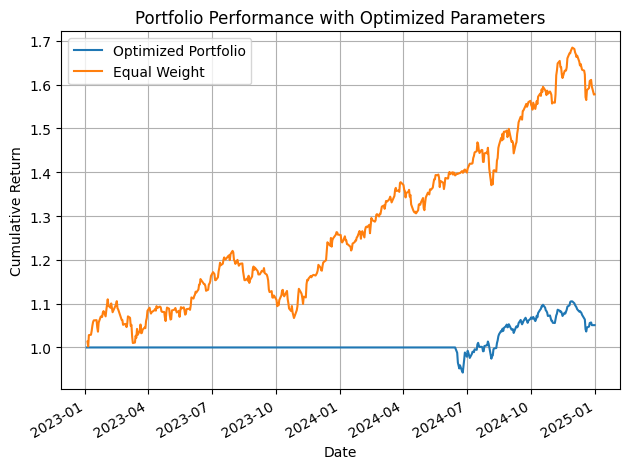

In [ ]:
# Define hyperparameter grid
param_grid = {
    'risk_aversion': [1.0, 2.0, 5.0, 10.0],
    'target_return': [None, 0.15, 0.20, 0.25],
    'shrinkage_method': ['ledoit_wolf', 'oracle_approximating'],
    'risk_free_rate': [0.01, 0.02, 0.03]
}

portfolio = pd.read_csv(pft_path, parse_dates=True, index_col="Date")

# Run hyperparameter tuning
results = hyperparameter_tune_optimizer(
    portfolio, 
    param_grid, 
    n_splits=5, 
    # objective="sharpe"  # Can be "sharpe", "return", or "risk"
)

# Print best parameters
print("RESULTS"+str(results))
print("Best Parameters:", results[0]["best_params"])
print("Best Score:", results[0]["best_score"])

# Run backtest with best parameters
backtest_results, weights_history = backtest_portfolio(portfolio, MarkowitzOptimizer(**results[0]["best_params"]))

# Plot backtest results
plt.figure(figsize=(12, 6))
backtest_results[['portfolio_cumulative', 'equal_weight_cumulative']].plot()
plt.title('Portfolio Performance with Optimized Parameters')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(['Optimized Portfolio', 'Equal Weight'])
plt.grid(True)
plt.tight_layout()
plt.savefig("backtest_results.png")

# Calculate performance metrics
portfolio_returns = backtest_results['portfolio'].dropna()

annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print(f"Annual Return: {annual_return:.4f}")
print(f"Annual Volatility: {annual_volatility:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")